### Objective
Understand **relationships between two variables** to:
- Select useful features
- Detect redundancy (multicollinearity)
- Anticipate model behavior
- Prevent leakage

### Types of Bivariate Analysis
| Case                      | Example         |
| ------------------------- | --------------- |
| Numerical <-> Numerical     | Age vs Income   |
| Numerical <-> Categorical   | Salary vs City  |
| Categorical <-> Categorical | City vs Gender  |
| Feature <-> Target          | Core ML insight |


In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "age": np.random.randint(18, 65, 500),
    "income": np.random.normal(60000, 15000, 500),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore"], 500),
    "purchased": np.random.choice([0, 1], 500)
})

Assume:
- `purchased` -> classification target

### Numerical <-> Numerical Analysis

#### Scatter Plot

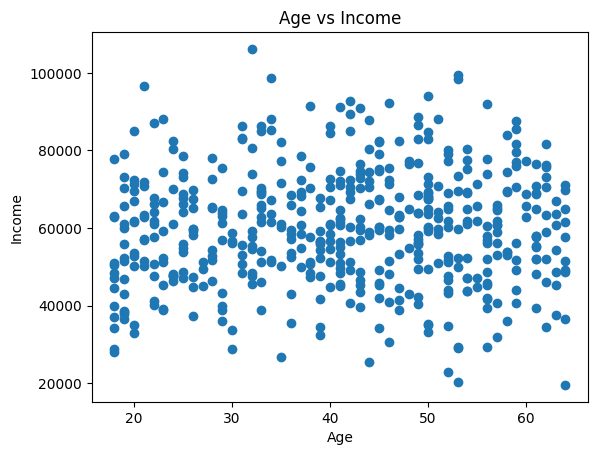

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["age"], df["income"])
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")
plt.show()

**ML Interpretation**
- Linear trend -> Linear Regression friendly
- Curve -> Non-linear model needed
- Random cloud -> Weak relationship

### Correlation

In [4]:
df[["age", "income"]].corr()

,age,income
age,1.000000,0.052181
income,0.052181,1.000000


**Types of Correlation (Important)**
- **Pearson** -> linear relationship
- **Spearman** -> monotonic (rank-based)

In [5]:
df[["age", "income"]].corr(method="spearman")

,age,income
age,1.000000,0.060895
income,0.060895,1.000000


**Thumb Rule**
- |corr| > 0.8 -> multicollinearity risk
- |corr| < 0.1 -> likely weak predictor

### Multicollinearity

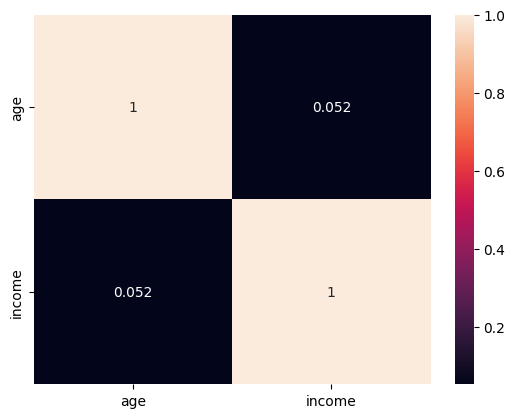

In [6]:
import seaborn as sns

sns.heatmap(df[["age", "income"]].corr(), annot=True)
plt.show()

**Why this matters**
- Linear & Logistic Regression coefficients become unstable
- Interpretability breaks
- Regularization needed (Ridge/Lasso)

### Numerical <-> Categorical Analysis
#### Boxplot
**Example: Income by City**

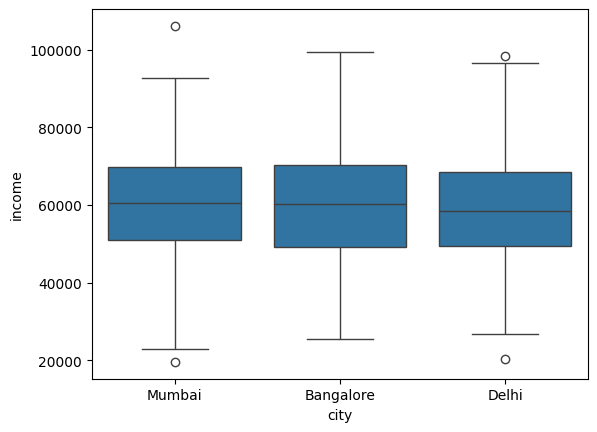

In [7]:
sns.boxplot(x="city", y="income", data=df)
plt.show()

**What to Observe**
- Different medians -> category is informative
- Overlapping boxes -> weak signal
- Outliers -> city-specific behavior

#### Group Statistics

In [8]:
df.groupby("city")["income"].agg(["mean", "median", "std"])

,mean,median,std
city,,,
Bangalore,60588.028237,60394.817783,14580.422899
Delhi,58771.918777,58381.571187,14416.160101
Mumbai,60317.452180,60628.388849,15447.734326


**ML Insight:**    
If category shows distinct numeric behavior -> good candidate encoding.

### Categorical <-> Categorical Analysis
#### Frequency Table
**Example: City vs Purchased**

In [9]:
pd.crosstab(df["city"], df["purchased"], normalize="index")

purchased,0,1
city,,
Bangalore,0.500000,0.500000
Delhi,0.494118,0.505882
Mumbai,0.517857,0.482143


**Interpretation:**
- Strong imbalance -> strong predictor
- Uniform distribution -> weak predictor

#### Chi-Square Test (Statistical Relevance)

In [10]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["city"], df["purchased"])
chi2, p, _, _ = chi2_contingency(contingency)

chi2, p

(np.float64(0.20582829906156086), np.float64(0.9022044248300551))

- `p < 0.05` -> statistically significant relationship

### Feature <-> Target Analysis
#### Numerical <-> Classification Target
**Example: Age vs Purchased**

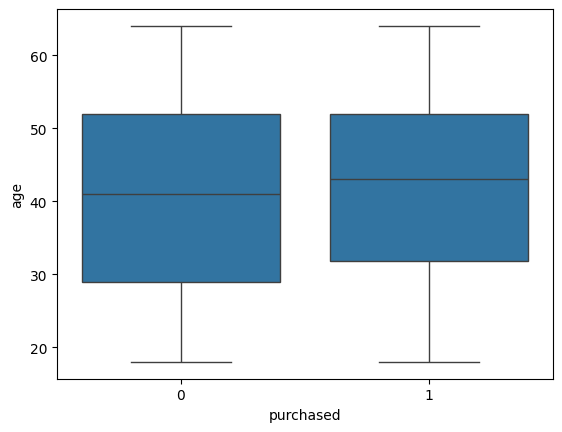

In [11]:
sns.boxplot(x="purchased", y="age", data=df)
plt.show()

**Interpretation:**
- Different distributions -> predictive power
- Similar distributions -> weak feature

#### Numerical Feature <-> Regression Target

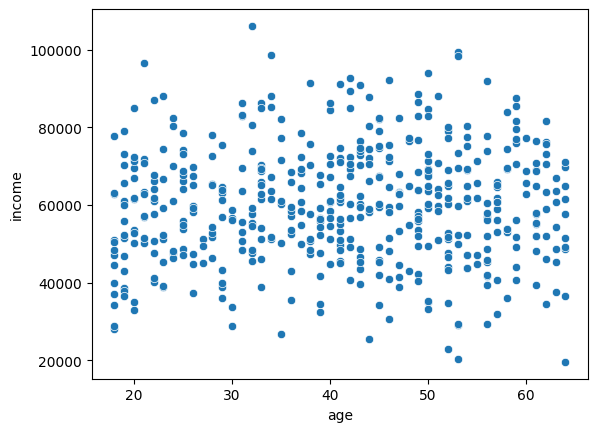

In [12]:
sns.scatterplot(x="age", y="income", data=df)
plt.show()

#### Categorical Feature <-> Target

In [13]:
df.groupby("city")["purchased"].mean()

city
Bangalore    0.500000
Delhi        0.505882
Mumbai       0.482143
Name: purchased, dtype: float64

### Mapping to Feature Engineering
| Observation                | Action               |
| -------------------------- | -------------------- |
| Strong correlation         | Keep feature         |
| High multicollinearity     | Drop / regularize    |
| Non-linear pattern         | Tree / Kernel models |
| Category-target dependency | Encoding strategy    |
